# Implementing a 2D analytical steady-state solution to the Richards equation.
We want to test the finite element method with Picard iterations against an analytical solution. Here, the Richards equation is given as <br>
$\frac{\partial \theta}{\partial t} - \nabla\cdot(k\nabla(z+h))$ which means that the hydraulic pressure head is negative above the saturation zone. <br>
In order to get to an analytical solution, the parametrizations are simplified to: <br>
$k=k_sk_r$ with $k_r = e^{\alpha h}$ (Gardner), $k_r = (\frac{\theta - \theta_r}{\theta_s - \theta_r})^m$ (Irmay) where $\alpha, m$ are parameters. For even further simplification we choose $m=1$ here. <br>
We choose $\Omega = [0, 15.24]\times[0, 15.24]$, $\alpha=0.19$ and $h_r = -15.24$.

## Achtung!
Hier arbeite ich wieder mit $h_c$ statt $h$ wobei $h_c=-h$!!! Das ist damit ich die Parametrisierungen Gardner vs van Genuchten vergleichen kann, allerdings konvergiert van Genuchten gerade gar nicht... 

In [1]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from visualization_fct import *

In [2]:
# Define constants
alpha = 0.19 # Gardner exponent
theta_r = 0.15 # residual water content
theta_s = 0.45 # saturated water content
xi = 0.56 # van Genuchten factor
n = 2 # van Genuchten exponent
L = a = 15.24 # height, length of box
h_r = -15.24 # pressure head when the soil is very dry
Ks = 3e-6 # saturated hydraulic conductivity


# Solution constants
h_0 = 1 - np.exp(alpha*h_r)
beta = np.sqrt(alpha**2/4 + (np.pi/a)**2)
beta_1 = np.sqrt(alpha**2/4 + (np.pi*2/a)**2)

Boundary conditions: <br>
Problem 1 (Dirichlet):
- $h=h_r$ on $x=0,~x=a,~z=0$
- $h = \frac{1}{\alpha}\ln(e^{\alpha h_r}+\bar h_0\sin(\frac{\pi x}{a}))$ with $\bar h_0 = 1-e^{\alpha h_r}$ on $z=L$

Problem 2 (Neumann, Dirichlet):
- $h=h_r$ on $z=0$
- no flow on $x=0,~x=a$
- $h=\frac{1}{\alpha} \ln(e^{\alpha h_r} + \frac{\bar h_0}{2}[1-\cos(\frac{2\pi x}{a})])$ on $z=L$


## Analytical solutions

In [3]:
def exact_specified_head(x, z_cor):
    bar_h = h_0 * np.sin(np.pi*x/a) * np.exp(alpha/2*(L-z_cor)) * np.sinh(beta*z_cor) / np.sinh(beta*L)
    h = 1/alpha * np.log(np.exp(alpha*h_r) + bar_h)
    return -h

def exact_no_flow(x, z_cor):
    factor = h_0/2 * np.exp(alpha/2*(L-z_cor))
    bar_h = factor * (np.sinh(alpha*z_cor/2) / np.sinh(alpha*L/2) - np.cos(2*np.pi*x/a) * np.sinh(beta_1*z_cor) / np.sinh(beta_1*L))
    return -1/alpha * np.log(np.exp(alpha*h_r) + bar_h)

In [4]:
# Grids
x_grid = np.linspace(0, a, 100)
z_grid = np.linspace(0, L, 100)
X, Z = np.meshgrid(x_grid, z_grid)

In [5]:
# Evaluate solutions on grid
def eval_head(x, z, fct):
    head = np.zeros((len(x), len(x)))
    for i, z_cor in enumerate(z):
        head[i, :] = fct(x, z_cor)
    return head

h_fix = eval_head(x_grid, z_grid, exact_specified_head)
h_no = eval_head(x_grid, z_grid, exact_no_flow)


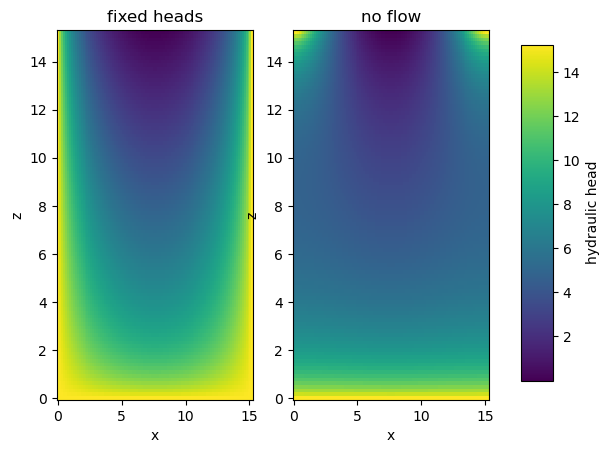

In [6]:
vmin = np.min([h_no, h_fix])
vmax = np.max([h_no, h_fix])

fig, ax = plt.subplots(1,2)
con1 = ax[0].pcolormesh(X, Z, h_fix, cmap=plt.cm.viridis, vmin=vmin, vmax=vmax)
ax[0].set_title("fixed heads")
ax[0].set_xlabel("x")
ax[0].set_ylabel("z")

con2 = ax[1].pcolormesh(X, Z, h_no, cmap=plt.cm.viridis, vmin=vmin, vmax=vmax)
ax[1].set_title("no flow")
ax[1].set_xlabel("x")
ax[1].set_ylabel("z")

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cbar = fig.colorbar(con2, cax=cbar_ax)
cbar.set_label("hydraulic head")



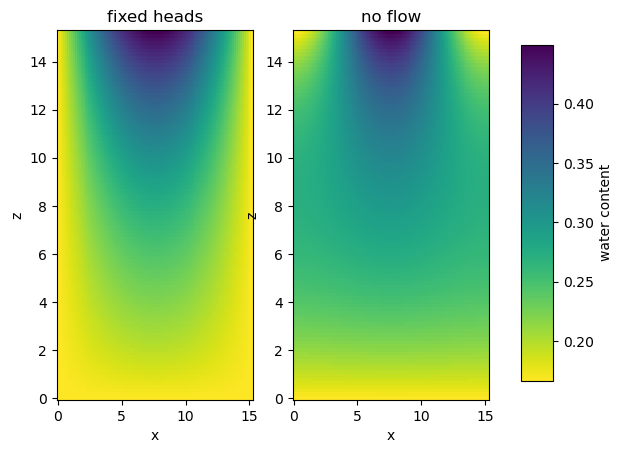

In [7]:
# plot water content
theta_fix = theta_r + (theta_s - theta_r)*np.exp(-alpha*h_fix)
theta_no = theta_r + (theta_s - theta_r)*np.exp(-alpha*h_no)

vmin = np.min([theta_no, theta_fix])
vmax = np.max([theta_no, theta_fix])

fig, ax = plt.subplots(1,2)
con1 = ax[0].pcolormesh(X, Z, theta_fix, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[0].set_title("fixed heads")
ax[0].set_xlabel("x")
ax[0].set_ylabel("z")

con2 = ax[1].pcolormesh(X, Z, theta_no, cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[1].set_title("no flow")
ax[1].set_xlabel("x")
ax[1].set_ylabel("z")

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cbar = fig.colorbar(con2, cax=cbar_ax)
cbar.set_label("water content")

## Discrete solutions

In [8]:
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    functionspace,
    dirichletbc,
    locate_dofs_geometrical,
    form,
    extract_function_spaces,
)
from dolfinx.fem.petsc import (
    LinearProblem, 
    NonlinearProblem, 
    create_matrix, 
    create_vector, 
    assemble_matrix, 
    assemble_vector,
    apply_lifting,
    set_bc,
    )
from dolfinx.mesh import create_unit_square, locate_entities, meshtags, create_rectangle, CellType
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
from ufl import (
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    dx,
    grad,
    inner,
    exp,
    lhs,
    rhs,
    derivative,
    conditional,
    sqrt,
    ln,
)

from petsc4py import PETSc

In [9]:
# Create mesh
domain = create_rectangle(MPI.COMM_WORLD, ((0,0), (15.24, 15.24)), (100,100), cell_type=CellType.quadrilateral)
V = functionspace(domain, ("CG", 1))
x = SpatialCoordinate(domain)

def van_Genuchten_kr(u):
    S = (1 + (xi * u)**n)**((1 - n) / n)
    kr = S**(0.5)*(1 - (1 - S**(n / (n - 1))) **((n - 1) / n))**2
    return kr

def Gardner_kr(u):
    return exp(-alpha*u)

In [10]:
# Define Dirichlet boundary conditions

def left_or_right(x):
    return np.logical_or(np.isclose(x[0], 0), np.isclose(x[0], a))

dofs_fix = locate_dofs_geometrical(
    V, lambda x: np.logical_or(left_or_right(x), np.isclose(x[1], 0)))
bc_fix = dirichletbc(Constant(domain, default_scalar_type(-h_r)), dofs_fix, V)

dofs_no = locate_dofs_geometrical(V, lambda x: np.isclose(x[1], 0))
bc_no = dirichletbc(Constant(domain, default_scalar_type(-h_r)), dofs_no, V)

def expr_h_fix(x):
    return -1/alpha*np.log(np.exp(alpha*h_r) + h_0*np.sin(np.pi*x[0]/a))

def expr_h_noflow(x):
    return -1/alpha*np.log(np.exp(alpha*h_r) + h_0/2*(1-np.cos(2*np.pi*x[0]/a)))


dofs_L = locate_dofs_geometrical(V, lambda x: np.isclose(x[1], L))

h_top_fix = Function(V)
h_top_fix.interpolate(expr_h_fix)
bc_top_fix = dirichletbc(h_top_fix, dofs_L)

h_top_no = Function(V)
h_top_no.interpolate(expr_h_noflow)
bc_top_no = dirichletbc(h_top_no, dofs_L)

### Problem 1: fixed head boundaries

In [11]:
# Initial guess: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.maximum(x[1], 0)

v = TestFunction(V)
uh = Function(V)
uh.interpolate(u_ini)
x = SpatialCoordinate(domain)
bc = [bc_fix, bc_top_fix]

F = inner(Ks * van_Genuchten_kr(uh) * grad(x[1] - uh), grad(v)) * dx
J = derivative(F, uh)


In [12]:
# Try with build-in version
petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-10,
    "snes_monitor": None,
    "ksp_error_if_not_converged": True,
    "ksp_type": "preonly",
    "ksp_rtol": 1e-10,
    "ksp_monitor": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

problem = NonlinearProblem(
    F,
    uh,
    bcs=bc,
    J=J,
    petsc_options=petsc_options,
    petsc_options_prefix="RichardsSNES_",
)

u_fix = problem.solve()
converged = problem.solver.getConvergedReason()
num_iter = problem.solver.getIterationNumber()
assert converged > 0, f"Solver did not converge, got {converged}."
print(
    f"Solver converged after {num_iter} iterations with converged reason {converged}."
)


  0 SNES Function norm 2.339783385743e+02
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 2.339783385743e+02
    1 KSP Residual norm 3.305223765919e-19
  1 SNES Function norm 8.419016589676e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.419016589676e-06
    1 KSP Residual norm 5.211525648842e-20
  2 SNES Function norm 8.418178751406e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.418178751406e-06
    1 KSP Residual norm 4.831555049768e-20
  3 SNES Function norm 8.417339949606e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.417339949606e-06
    1 KSP Residual norm 4.832109181014e-20
  4 SNES Function norm 8.409611640954e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.409611640954e-06
    1 KSP Residual norm 4.275718649132e-20
  5 SNES Function norm 8.401410842951e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.401410842951e-06
    1 KSP R

2026-03-31 09:40:15.767 (  11.516s) [    75B1FDCBF600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


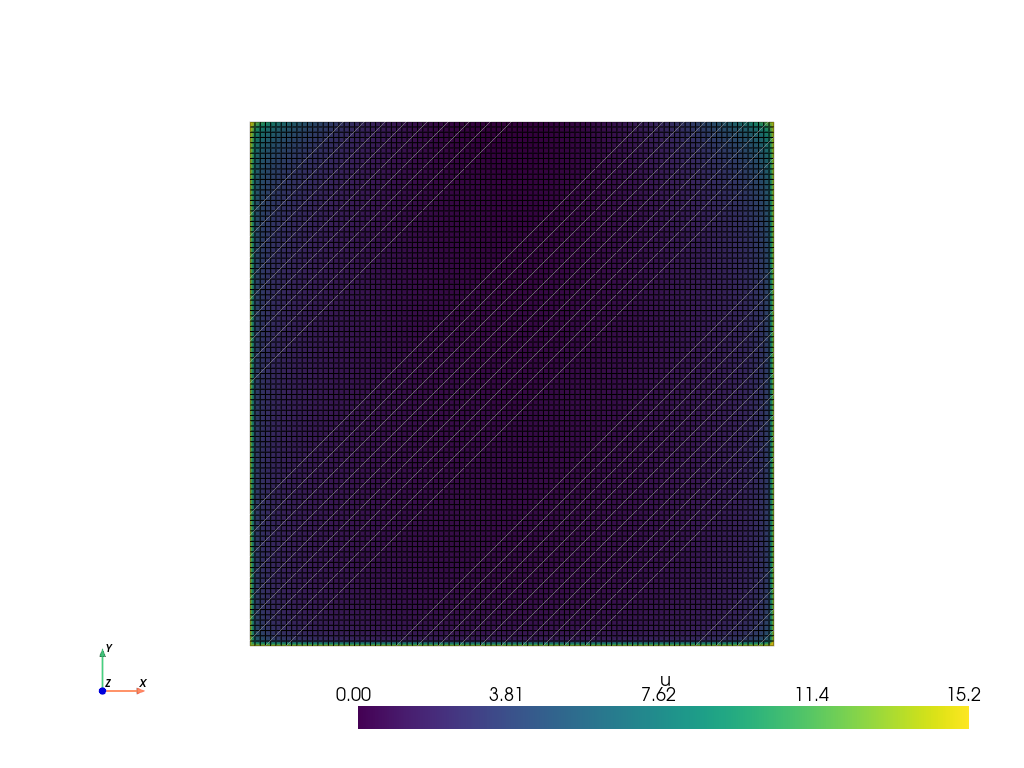

In [13]:
plotScalarFunction(V, u_fix)

### Try with better initial guess (from Gardner parametrization first few iterations done)

In [19]:
# Initial guess: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.maximum(x[1], 0)

v = TestFunction(V)
uh = Function(V)
uh.interpolate(u_ini)
x = SpatialCoordinate(domain)
bc = [bc_fix, bc_top_fix]

F = inner(Ks * Gardner_kr(uh) * grad(x[1] - uh), grad(v)) * dx
residual = form(F)
J = derivative(F, uh)
jacobian = form(J)

# Setup of iteration-independent structures
A = create_matrix(jacobian)
L = create_vector(extract_function_spaces(residual))

# Create linear solver and vector for delta_u
solver = PETSc.KSP().create(domain.comm)
solver.setType("preonly")
solver.getPC().setType("lu")
solver.getPC().setFactorSolverType("mumps")
solver.setErrorIfNotConverged(True)

solver.setOperators(A)
du = Function(V)

In [20]:
# Newton iteration by hand
i = 0
maxiter = 10
tol = 1e-6

while i < maxiter:
    # Assemble Jacobian and residual
    with L.localForm() as locL:
        locL.set(0)
    A.zeroEntries()
    assemble_matrix(A, jacobian, bcs=bc)
    A.assemble()
    assemble_vector(L, residual)

    # Apply Dirichlet boundary conditions delta_u@boundary = u_D - u_k@boundary
    apply_lifting(L, [jacobian], [bc], x0=[uh.x.petsc_vec], alpha=-1.0) # L_new = L - alpha*Jacobian*(u_D-u_{k})
    L.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(L, bc, uh.x.petsc_vec, alpha = -1.0)

    # Scale residual by -1
    L.scale(-1)
    L.ghostUpdate(addv=PETSc.InsertMode.INSERT_VALUES, mode=PETSc.ScatterMode.FORWARD)

    # Solve linear problem A*du=-L
    solver.solve(L, du.x.petsc_vec)
    du.x.scatter_forward()

    # Update u_{k+1} = u_k + delta_u_k
    uh.x.array[:] += du.x.array
    i += 1

    # Compute norm of update
    correction_norm = du.x.petsc_vec.norm(0)
    print(f"Iteration {i}: Correction norm ||du|| = {correction_norm:.2e}")

    if correction_norm < tol:
        print(f"Iteration stopped because ||delta_u||={correction_norm:.2e} is smaller than {tol}.")
        break

Iteration 1: Correction norm ||du|| = 9.02e+04
Iteration 2: Correction norm ||du|| = 1.74e+05
Iteration 3: Correction norm ||du|| = 3.32e+04
Iteration 4: Correction norm ||du|| = 2.57e+04
Iteration 5: Correction norm ||du|| = 1.90e+04
Iteration 6: Correction norm ||du|| = 1.34e+04
Iteration 7: Correction norm ||du|| = 8.67e+03
Iteration 8: Correction norm ||du|| = 4.85e+03
Iteration 9: Correction norm ||du|| = 2.05e+03
Iteration 10: Correction norm ||du|| = 4.98e+02


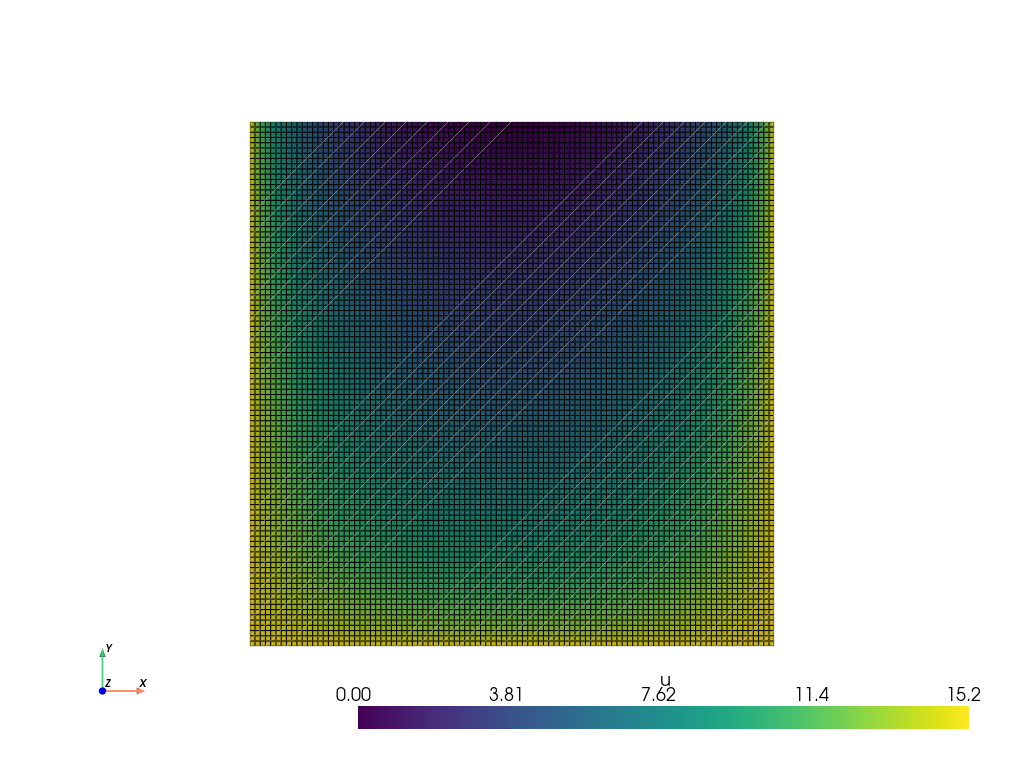

In [21]:
plotScalarFunction(V, uh)

In [17]:
F = inner(Ks * van_Genuchten_kr(uh) * grad(x[1] - uh), grad(v)) * dx
J = derivative(F, uh)

petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-10,
    "snes_monitor": None,
    "ksp_error_if_not_converged": True,
    "ksp_type": "preonly",
    "ksp_rtol": 1e-10,
    "ksp_monitor": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

problem = NonlinearProblem(
    F,
    uh,
    bcs=bc,
    J=J,
    petsc_options=petsc_options,
    petsc_options_prefix="RichardsSNES_",
)

u_fix = problem.solve()
converged = problem.solver.getConvergedReason()
num_iter = problem.solver.getIterationNumber()
assert converged > 0, f"Solver did not converge, got {converged}."
print(
    f"Solver converged after {num_iter} iterations with converged reason {converged}."
)

  0 SNES Function norm 8.302541456400e-07
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.302541456400e-07
    1 KSP Residual norm 5.105079340149e-20
  1 SNES Function norm 8.294244479304e-07
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.294244479304e-07
    1 KSP Residual norm 4.572587880626e-20
  2 SNES Function norm 8.285941335991e-07
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.285941335991e-07
    1 KSP Residual norm 4.504262069695e-20
  3 SNES Function norm 8.244452659146e-07
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.244452659146e-07
    1 KSP Residual norm 4.042228727239e-20
  4 SNES Function norm 8.161234679976e-07
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.161234679976e-07
    1 KSP Residual norm 3.530068768711e-20
  5 SNES Function norm 8.079051279853e-07
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 8.079051279853e-07
    1 KSP R

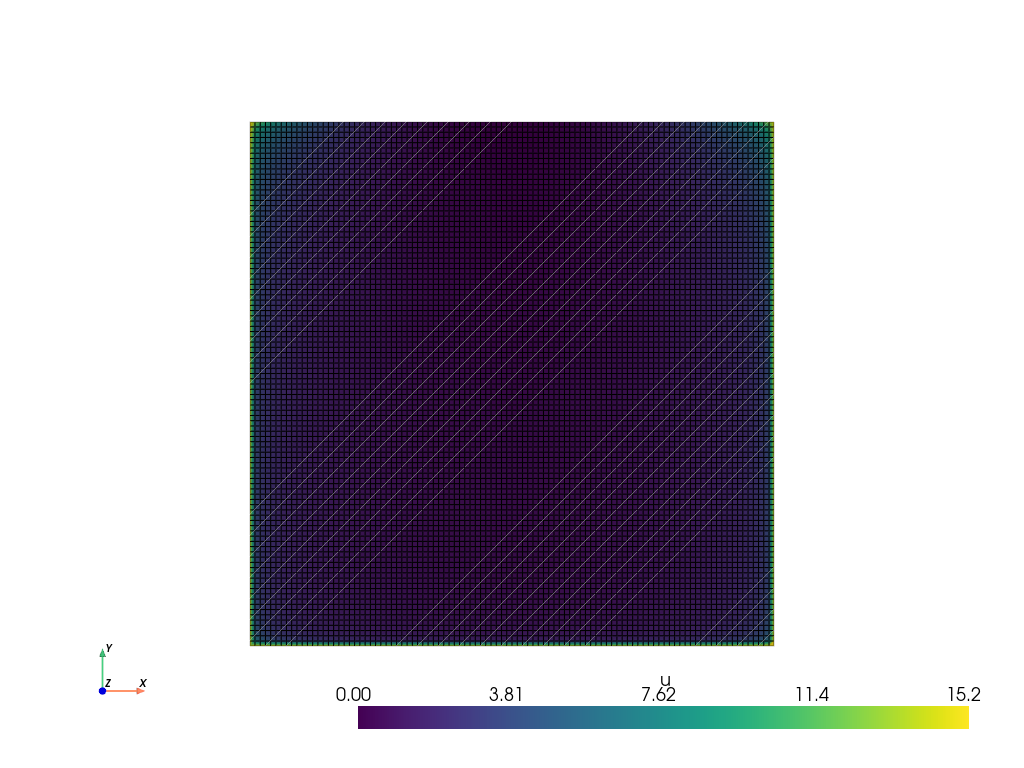

In [18]:
plotScalarFunction(V, uh)

Even with a quite good initial guess, the van Genuchten paramterization converges to the wrong solution.

### Problem 2: no flow boundaries

In [14]:
# Initial guess: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.maximum(x[1], 0)

v = TestFunction(V)
uh = Function(V)
uh.interpolate(u_ini)
x = SpatialCoordinate(domain)
bc = [bc_no, bc_top_no]

F = inner(Ks * van_Genuchten_kr(uh) * grad(x[1] - uh), grad(v)) * dx
J = derivative(F, uh)


In [15]:
# Try with build-in version
petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-10,
    "snes_monitor": None,
    "ksp_error_if_not_converged": True,
    "ksp_type": "preonly",
    "ksp_rtol": 1e-10,
    "ksp_monitor": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

problem = NonlinearProblem(
    F,
    uh,
    bcs=bc,
    J=J,
    petsc_options=petsc_options,
    petsc_options_prefix="RichardsSNES_",
)

u_no = problem.solve()
converged = problem.solver.getConvergedReason()
num_iter = problem.solver.getIterationNumber()
assert converged > 0, f"Solver did not converge, got {converged}."
print(
    f"Solver converged after {num_iter} iterations with converged reason {converged}."
)

  0 SNES Function norm 1.901756355572e+02
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 1.901756355572e+02
    1 KSP Residual norm 3.342593139087e-19
  1 SNES Function norm 7.428094833466e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 7.428094833466e-06
    1 KSP Residual norm 4.796329121593e-20
  2 SNES Function norm 7.427357433261e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 7.427357433261e-06
    1 KSP Residual norm 4.451488603291e-20
  3 SNES Function norm 7.426617979227e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 7.426617979227e-06
    1 KSP Residual norm 4.388538545325e-20
  4 SNES Function norm 7.419649502188e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 7.419649502188e-06
    1 KSP Residual norm 3.558307025568e-20
  5 SNES Function norm 7.412462473016e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 7.412462473016e-06
    1 KSP R

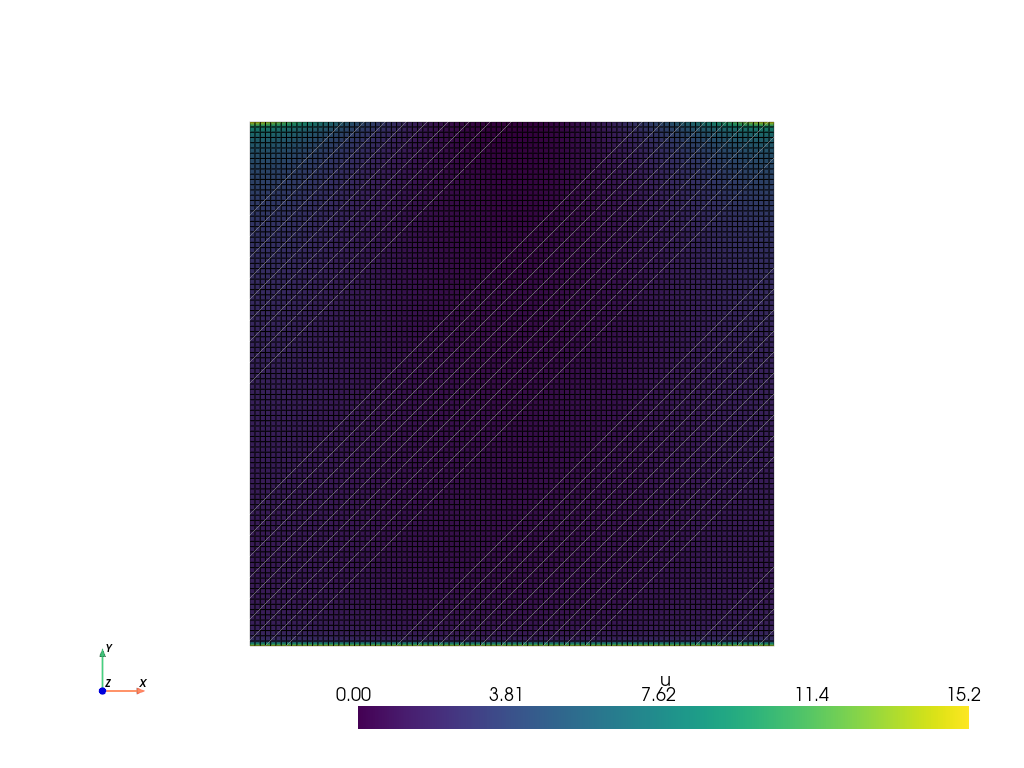

In [16]:
plotScalarFunction(V, u_no)

## Comparing the solutions

In [17]:
def eval_try(x, z, u):
    h = np.zeros((len(z), len(x)))
    for i, z_cor in enumerate(z):
        p = np.vstack([x, np.full(len(x), z_cor), np.zeros(len(x))])
        pts, values = evaluate_fct(domain, p, u)
        h[i, :] = np.array(values).flatten()
    return h

heads_fix = eval_try(x_grid, z_grid, [u_fix])
heads_no = eval_try(x_grid, z_grid, [u_no])

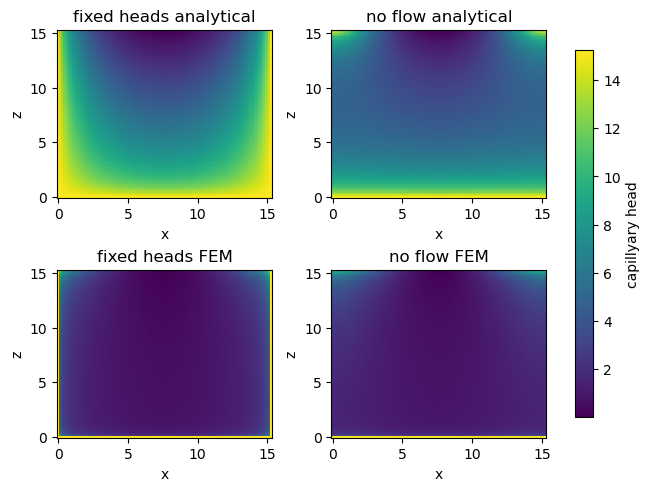

In [18]:
vmin = np.min([h_no, h_fix, heads_fix, heads_no])
vmax = np.max([h_no, h_fix, heads_fix, heads_no])

fig, ax = plt.subplots(2,2, layout="constrained")
con1 = ax[0,0].pcolormesh(X, Z, h_fix, cmap=plt.cm.viridis, vmin=vmin, vmax=vmax)
ax[0,0].set_title("fixed heads analytical")
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("z")

con2 = ax[0,1].pcolormesh(X, Z, h_no, cmap=plt.cm.viridis, vmin=vmin, vmax=vmax)
ax[0,1].set_title("no flow analytical")
ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel("z")

con3 = ax[1,0].pcolormesh(X, Z, heads_fix, cmap=plt.cm.viridis, vmin=vmin, vmax=vmax)
ax[1,0].set_title("fixed heads FEM")
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("z")

con4 = ax[1,1].pcolormesh(X, Z, heads_no, cmap=plt.cm.viridis, vmin=vmin, vmax=vmax)
ax[1,1].set_title("no flow FEM")
ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel("z")


cbar = fig.colorbar(con2, ax=ax.ravel().tolist(), shrink=0.9)
cbar.set_label("capillyary head")


In [19]:
p1_err = h_fix - heads_fix
p2_err = h_no - heads_no
print(f"Problem 1: || . ||_inf = {np.linalg.norm(p1_err.flatten(), ord=np.inf):.2e}, || . ||_2 = {np.linalg.norm(p1_err.flatten(), ord=2):.2e}.")
print(f"Problem 2: || . ||_inf = {np.linalg.norm(p2_err.flatten(), ord=np.inf):.2e}, || . ||_2 = {np.linalg.norm(p2_err.flatten(), ord=2):.2e}.")

Problem 1: || . ||_inf = 1.27e+01, || . ||_2 = 7.05e+02.
Problem 2: || . ||_inf = 1.21e+01, || . ||_2 = 4.65e+02.


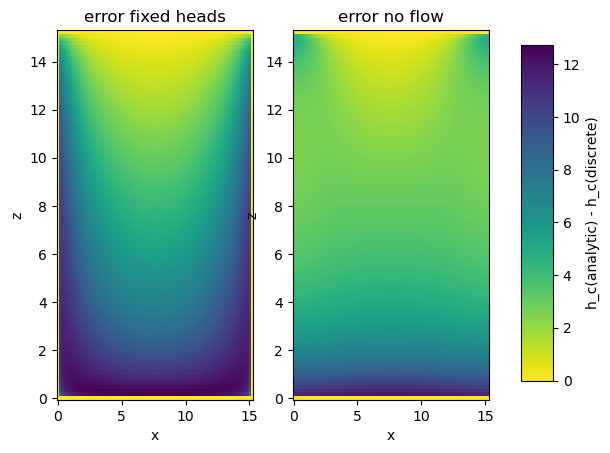

In [20]:
vmin = np.min([np.abs(p1_err), np.abs(p2_err)])
vmax = np.max([np.abs(p1_err), np.abs(p2_err)])

fig, ax = plt.subplots(1,2)
con1 = ax[0].pcolormesh(X, Z, np.abs(p1_err), cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[0].set_title("error fixed heads")
ax[0].set_xlabel("x")
ax[0].set_ylabel("z")

con1 = ax[1].pcolormesh(X, Z, np.abs(p2_err), cmap=plt.cm.viridis_r, vmin=vmin, vmax=vmax)
ax[1].set_title("error no flow")
ax[1].set_xlabel("x")
ax[1].set_ylabel("z")

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cbar = fig.colorbar(con1, cax=cbar_ax)
cbar.set_label("h_c(analytic) - h_c(discrete)")

### Compare parametrizations
and find optimal alpha for real life parameters :)

0.4042485521207381


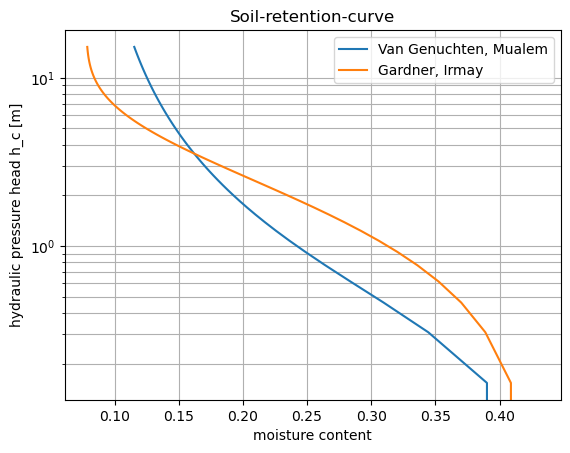

In [21]:
alpha = 0.3 # Gardner exponent
theta_r = 0.078 # residual water content
theta_s = 0.43 # saturated water content
xi = 3.6 # van Genuchten factor
n = 1.56 # van Genuchten exponent
L = a = 15.24 # height, length of box
h_r = -15.24 # pressure head when the soil is very dry
Ks = 2.89e-6 # saturated hydraulic conductivity


# Plot soil retention curve for both parametrizations.

h_test = np.linspace(0, -h_r, 100)

def Saturation(h_c):
    S = (1 + (xi * h_c)**n)**(1-1/n)
    return S

theta_vG = theta_r + (theta_s - theta_r)/Saturation(h_test)



def loss_fct(alpha):
    alpha = alpha[0]
    theta_vG = theta_r + (theta_s - theta_r)/Saturation(h_test)
    theta_G = theta_r + (theta_s - theta_r)*np.exp(-alpha*h_test)
    return np.linalg.norm(theta_vG - theta_G, ord=2)**2


from scipy.optimize import minimize # type: ignore
alpha0 = np.array([0.3])
result = minimize(loss_fct, alpha0, method="L-BFGS-B", bounds=[(0, None)])

alpha_opt = result.x[0]
print(alpha_opt)


theta_G = theta_r + (theta_s - theta_r)*np.exp(-alpha_opt*h_test)

fig5, ax5 = plt.subplots(1, 1)
ax5.semilogy(theta_vG, h_test, label = "Van Genuchten, Mualem")
ax5.semilogy(theta_G, h_test, label = "Gardner, Irmay")
ax5.set_xlabel("moisture content")
ax5.set_ylabel("hydraulic pressure head h_c [m]")
ax5.set_title("Soil-retention-curve")
ax5.grid(which="both")
ax5.legend()
